In [ ]:
PROJ_NAME = "kyber_poly_tomsg_ttest"
FW_DIR = f"../fw/victims/{PROJ_NAME}"
BIN_FILE = f"{FW_DIR}/{PROJ_NAME}"
BOOTLOADER = "python3 ../../sdk/toolchain/bootloader.py"
BS_FILE = "../vivado/risqrypt_cw305.runs/impl_1/fpga_top.bit"
TARGET_PLATFORM = 'CW305_100t'
KYBER_K = 3
LABEL = "polytomsg_en_nttrst_x2xen"

In [2]:
import sys
sys.path.insert(0, "../")

from host.CW305_rq import CW305_rq

In [3]:
import chipwhisperer as cw

In [4]:
scope = cw.scope()
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

In [5]:
target = cw.target(scope, CW305_rq, force=True, fpga_id='100t', platform='cw305', bsfile=BS_FILE)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [6]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(10E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [7]:
if scope._is_husky:
    scope.clock.clkgen_freq = 20e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 2
    scope.adc.stream_mode = True
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.adc_src = "extclk_x2"

In [8]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [9]:
if KYBER_K == 2:
    from kyber_py.kyber.default_parameters import Kyber512 as kyber_py
elif KYBER_K == 3:
    from kyber_py.kyber.default_parameters import Kyber768 as kyber_py
elif KYBER_K == 4:
    from kyber_py.kyber.default_parameters import Kyber1024 as kyber_py
else:
    raise ValueError("Invalid KYBER_K")

In [10]:
target.output_len = 0
scope.adc.samples = 40000
scope.gain.db = 12

In [11]:
import os
from Crypto.Hash import SHAKE256


def set_ct(seed = os.urandom(16)):
    def rng(len):
        assert len == 32
        return seed
    kyber_py.random_bytes = rng
    target.simpleserial_write('k', seed)
    ct_dut = target.simpleserial_read('r', 4)
    ct = SHAKE256.new(seed).read(4)
    assert ct == ct_dut, "Ciphertext mismatch!"
    return ct

def set_pk(seed = os.urandom(16)):
    def rng(len):
        assert len == 32
        return seed
    kyber_py.random_bytes = rng
    target.simpleserial_write('g', seed)
    pk_dut = target.simpleserial_read('r', 4)
    pk, _ = kyber_py.keygen()
    # assert pk[:4] == pk_dut, "Public key mismatch!"
    return pk


In [ ]:
def ths_name(random, prng_off=False, N=1000, label=LABEL):
    if label is not None:
        return f"traces/{PROJ_NAME}_k{KYBER_K}_N{N}_prngoff{int(prng_off)}_r{random}_{label}"
    else:
        return f"traces/{PROJ_NAME}_k{KYBER_K}_N{N}_prngoff{int(prng_off)}_r{random}"

In [16]:
from tqdm.notebook import tnrange
import numpy as np
import estraces

def collect_traces(N=5000, prng_off=False):

    filename_0 = ths_name(random=0, prng_off=prng_off, N=N)
    es_writer_0 = estraces.ETSWriter(filename=filename_0, overwrite=False)
    filename_1 = ths_name(random=1, prng_off=prng_off, N=N)
    es_writer_1 = estraces.ETSWriter(filename=filename_1, overwrite=False)

    ct = set_ct(os.urandom(16))
    pk = set_pk(os.urandom(16))

    const_seed = os.urandom(32)

    for _ in tnrange(N, desc='Capturing traces'):

        # const input
        ret = cw.capture_trace(scope, target, const_seed, None)
        if not ret:
            print("Failed capture")
            continue

        es_writer_0.write_samples(np.array(ret.wave))
        es_writer_0.write_metadata('s', np.frombuffer(const_seed))

        # rand input
        seed = os.urandom(32)
        ret = cw.capture_trace(scope, target, seed, None)
        if not ret:
            print("Failed capture")
            continue
        es_writer_1.write_samples(np.array(ret.wave))
        es_writer_1.write_metadata('s', np.frombuffer(seed))


    es_writer_0.close()
    es_writer_1.close()

In [ ]:
def read_ths(N=5000, prng_off=False, label=LABEL):
    filename_0 = ths_name(random=0, prng_off=prng_off, N=N, label=label)
    ths_0 = estraces.read_ths_from_ets_file(filename_0)
    filename_1 = ths_name(random=1, prng_off=prng_off, N=N, label=label)
    ths_1 = estraces.read_ths_from_ets_file(filename_1)
    return ths_0, ths_1

# PRNG=OFF

In [17]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2 PRNG_OFF=1

-DKYBER_K=3 -DPRNG_OFF -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_indcca_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_indcca_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../../../fw/kyber_hw/kem.c ../../../../fw/kyber_hw/masked_kem.c ../../../../fw/kyber_hw/verify.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk

/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .init   -j .text kyber_indcca_dec_ttest.elf kyber_indcca_dec_ttest.inst.bin
/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .rodata -j .data kyber_indcca_dec_ttest.elf kyber_indcca_dec_ttest.data.bin
python3 ../../../../sdk/toolchain/rom_generator.py kyber_indcca_dec_ttest.bin kyber_indcca_dec_ttest.mem 
Error: The file kyber_indcca_dec_ttest.bin was not found.
/opt/riscv/bin/riscv64-unknown-elf-size -B kyber_indcca_dec_ttest.elf
   text	   data	    bss	    dec	    hex	filename
  18392	      0	  15012	  33404	   827c	kyber_indcca_dec_ttest.elf


In [18]:
%%bash -s "$BIN_FILE" "$BOOTLOADER"
$2 -f $1 -q

Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin


../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin: 100%|██████████| 16.8k/16.8k [00:16<00:00, 1.00kB/s]


File transmission complete for ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin.
Sending file: ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin


../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin: 100%|██████████| 1.57k/1.57k [00:01<00:00, 901B/s]


File transmission complete for ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin.
Program load complete.
Serial port closed.


In [21]:
collect_traces(N=10, prng_off=True)

(ChipWhisperer Target WARNING|File SimpleSerial.py:414) Unexpected start to command: 0


AssertionError: Ciphertext mismatch!

In [20]:
ths_0, ths_1 = read_ths(N=10, prng_off=True)

AttributeError: File traces/kyber_indcca_dec_ttest_k3_N10_prngoff1_r0_polytomsg_en_nttrst_x2xdis does not exist.

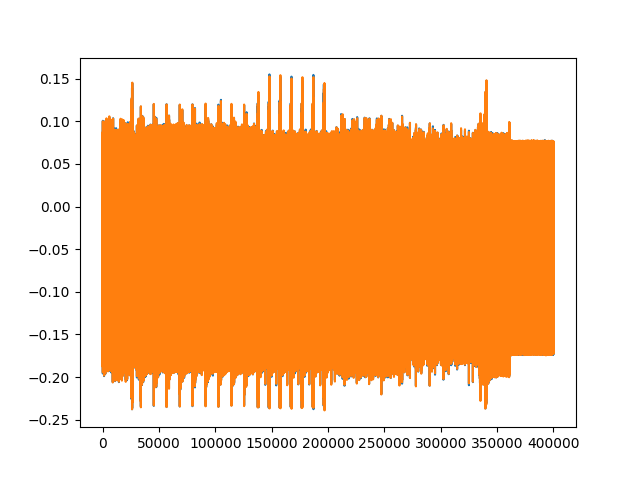

In [26]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

%matplotlib widget

mean_trace_0 = np.mean(np.array(ths_0.samples[:]), axis=0)
mean_trace_1 = np.mean(np.array(ths_1.samples[:]), axis=0)
ax.plot(mean_trace_0)
ax.plot(mean_trace_1)

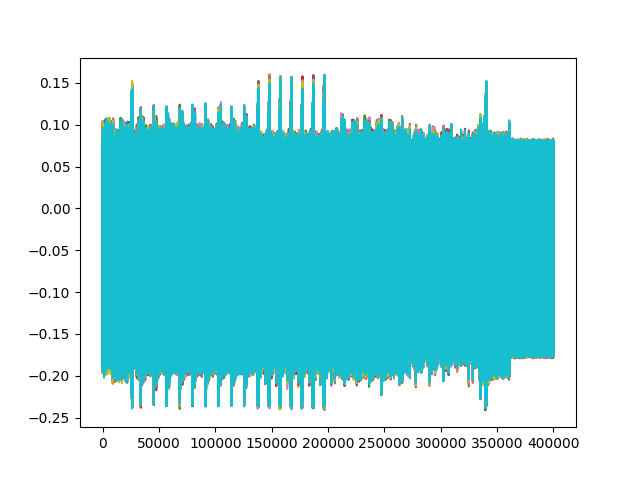

In [27]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

for i in range(5):
    ax.plot(ths_0.samples[i])

for i in range(5):
    ax.plot(ths_1.samples[i])

In [24]:
import scared

ttest = scared.ttest.TTestAnalysis()

container = scared.TTestContainer(ths_0, ths_1)

ttest.run(container)

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


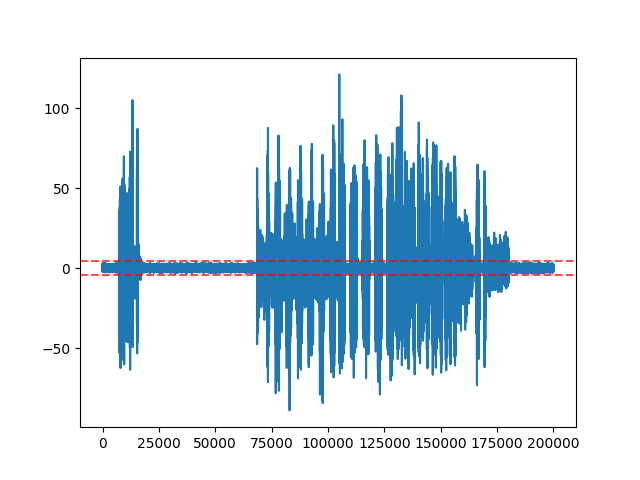

In [25]:
from matplotlib import pyplot as plt

%matplotlib widget

fig, ax = plt.subplots()

ax.plot(ttest.result)
ax.axhline(y=4.5, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=-4.5, color='red', linestyle='--', alpha=0.7)

# PRNG=ON

In [19]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_indcca_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_indcca_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../../../fw/kyber_hw/kem.c ../../../../fw/kyber_hw/masked_kem.c ../../../../fw/kyber_hw/verify.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c

In [20]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_indcca_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_indcca_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../../../fw/kyber_hw/kem.c ../../../../fw/kyber_hw/masked_kem.c ../../../../fw/kyber_hw/verify.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c

In [21]:
%%bash -s "$BIN_FILE" "$BOOTLOADER"
$2 -f $1 -q

Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin


../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin: 100%|██████████| 9.65k/9.65k [00:09<00:00, 1.04kB/s]


File transmission complete for ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin.
Sending file: ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin


../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin: 100%|██████████| 2.08k/2.08k [00:02<00:00, 895B/s]


File transmission complete for ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin.
Program load complete.
Serial port closed.


In [22]:
collect_traces(N=5000, prng_off=False)

Capturing traces:   0%|          | 0/5000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/kyber_indcca_dec_ttest_k3_N5000_prngoff0_r0_polytomsg_en_nttrst_x2xen', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/kyber_indcca_dec_ttest_k3_N5000_prngoff0_r1_polytomsg_en_nttrst_x2xen', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).


In [19]:
ths_0, ths_1 = read_ths(N=5000, prng_off=False)

In [22]:
import scared

ttest = scared.ttest.TTestAnalysis()

container = scared.TTestContainer(ths_0[:5000], ths_1[:5000], frame=range(0,50000))

ttest.run(container)

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


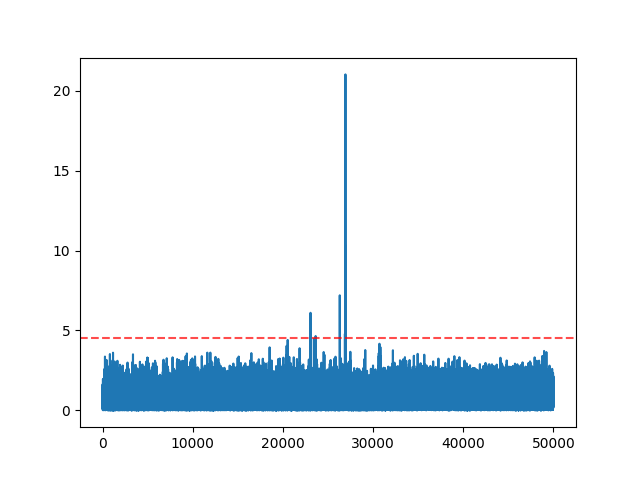

In [23]:
from matplotlib import pyplot as plt

%matplotlib widget

fig, ax = plt.subplots()

ax.plot(np.abs(ttest.result))
ax.axhline(y=4.5, color='red', linestyle='--', alpha=0.7)
#ax.axhline(y=-4.5, color='red', linestyle='--', alpha=0.7)

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


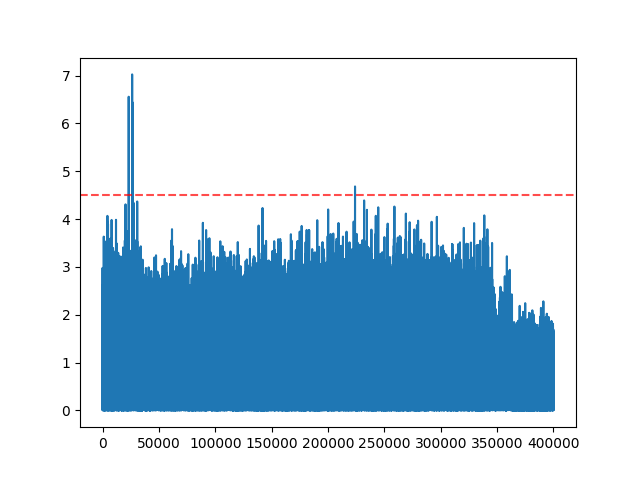

In [24]:
from matplotlib import pyplot as plt

%matplotlib widget

fig, ax = plt.subplots()

ax.plot(np.abs(ttest.result))
ax.axhline(y=4.5, color='red', linestyle='--', alpha=0.7)
#ax.axhline(y=-4.5, color='red', linestyle='--', alpha=0.7)